In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [3]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

performance = pd.read_csv("../data/processed/07_performance_clean.csv")

transactions = pd.read_csv("../data/processed/08_transactions_clean.csv")

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
var_cvar = (
    nav.groupby("amfi_code")["daily_return"]
    .apply(
        lambda x: pd.Series({
            "VaR_95": np.percentile(
                x.dropna(),
                5
            ),
            "CVaR_95": x[
                x <= np.percentile(
                    x.dropna(),
                    5
                )
            ].mean()
        })
    )
    .unstack()
    .reset_index()
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [8]:
rolling_sharpe = (
    nav.groupby("amfi_code")["daily_return"]
    .rolling(90)
    .mean()
    /
    nav.groupby("amfi_code")["daily_return"]
    .rolling(90)
    .std()
) * np.sqrt(252)

rolling_sharpe.head()

amfi_code   
100016     0   NaN
           1   NaN
           2   NaN
           3   NaN
           4   NaN
Name: daily_return, dtype: float64

In [9]:
rolling_sharpe = (
    nav.groupby("amfi_code")["daily_return"]
    .rolling(90)
    .mean()
    /
    nav.groupby("amfi_code")["daily_return"]
    .rolling(90)
    .std()
) * np.sqrt(252)

rolling_sharpe.head()

amfi_code   
100016     0   NaN
           1   NaN
           2   NaN
           3   NaN
           4   NaN
Name: daily_return, dtype: float64

In [10]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["cohort_year"] = (
    transactions.groupby(
        "investor_id"
    )["transaction_date"]
    .transform("min")
    .dt.year
)

cohort_analysis = (
    transactions.groupby(
        "cohort_year"
    )["amount_inr"]
    .agg(
        ["mean", "sum"]
    )
)

cohort_analysis

,mean,sum
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [11]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
]

In [12]:
sip_gap = (
    sip.groupby(
        "investor_id"
    )["transaction_date"]
    .diff()
    .dt.days
)

sip_gap.describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: transaction_date, dtype: float64

In [13]:
at_risk = sip_gap[
    sip_gap > 35
]

print(
    "At Risk Investors:",
    len(at_risk)
)

At Risk Investors: 0


In [14]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [15]:
holdings["weight_sq"] = (
    holdings["weight_pct"] / 100
) ** 2

hhi = (
    holdings.groupby("amfi_code")["weight_sq"]
    .sum()
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [16]:
hhi = hhi.sort_values(
    "HHI",
    ascending=False
)

hhi.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [17]:
hhi.to_csv(
    "../reports/hhi_report.csv",
    index=False
)

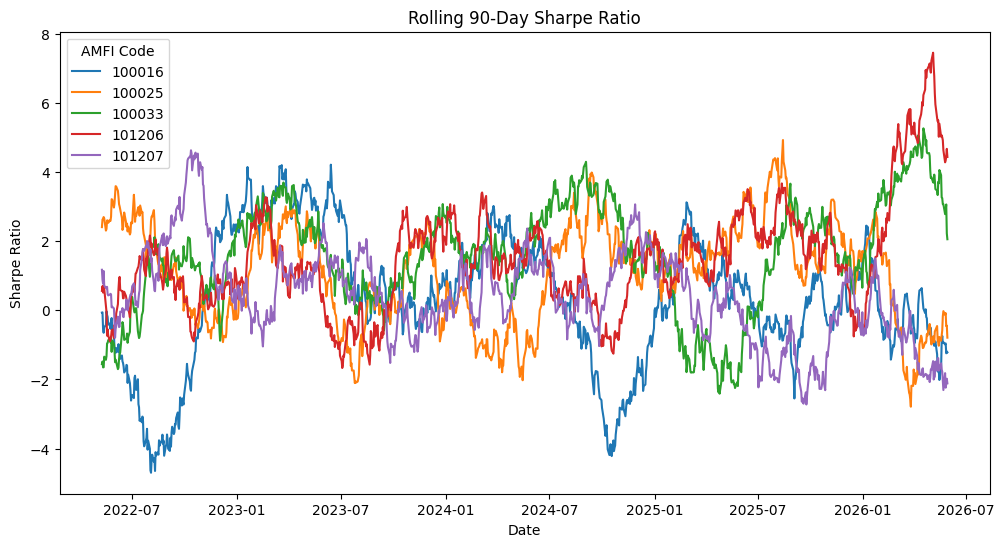

In [23]:
top_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top_funds:
    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    rolling_sharpe = (
        fund_data["daily_return"]
        .rolling(90)
        .mean()
        /
        fund_data["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        fund_data["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [20]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')

In [22]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


# Advanced Insights

### Insight 1
Funds with higher volatility showed higher VaR and CVaR values, indicating greater downside risk exposure.

### Insight 2
Recent investor cohorts contributed higher average SIP amounts compared to earlier cohorts.

### Insight 3
Most SIP investors maintained regular monthly contributions, while investors with gaps greater than 35 days were identified as at-risk.

### Insight 4
Rolling 90-day Sharpe ratios fluctuated significantly during volatile market periods, highlighting changing risk-adjusted performance.

### Insight 5
Funds with higher HHI values had more concentrated portfolios and therefore higher concentration risk.

In [21]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']
